In [ ]:
using Plots

T = Float64;

include("cheb.jl")



MultiGridMultiMethod (generic function with 1 method)

In [64]:
Ndom = 4;
global const z_boundaries = [ii * T(1.)/Ndom for ii in 0:Ndom]; #Boundaries of grid domains.
global const domain_sizes = [7,20,20,40]; #sizes of all domains.
global const diff_orders = [0,0,0,4]; #order=0 -> spectral, o/wise finite diff


In [65]:
diff2_mats, diff1_mats, grids, damp_mats = MultiGridMultiMethod(z_boundaries, domain_sizes, diff_orders)

(Any[[5525.333333333343 -8985.708389480282 … -1595.6249438530617 746.6666666666667; 2738.2150202128996 -4010.6666666666683 … -170.66666666666725 77.78497978710259; … ; 77.78497978710266 -170.66666666666737 … -4010.6666666666742 2738.215020212904; 746.6666666666674 -1595.6249438530635 … -8985.708389480298 5525.333333333354], [556031.9999999696 -885559.5433433003 … 15465.02193607687 -7679.999999999904; 258635.62491060884 -370685.2671450153 … 1214.0786230069748 -602.7591331951052; … ; -602.7591331951046 1214.078623006974 … -370685.26714501536 258635.62491060892; -7679.999999999902 15465.021936076868 … -885559.5433433005 556031.99999997], [556031.9999999696 -885559.5433433002 … 15465.02193607687 -7679.999999999904; 258635.6249106088 -370685.26714501524 … 1214.078623006975 -602.7591331951054; … ; -602.7591331951049 1214.0786230069743 … -370685.2671450153 258635.62491060892; -7679.999999999902 15465.02193607687 … -885559.5433433005 556031.9999999701], [75205.00000000041 -232544.00000000122 …

In [72]:
testfun = x->sin.(x.^2);
testder = x->2 .* x .* cos(x.^2);

In [73]:
function ComputeSingleDerivative(Vec; deg = 1)
    #Takes a single variable vector, returns its first, second or 'damping' derivative only.
    DVec = [similar(v) for v in Vec];

    Threads.@threads for dom in 1:Ndom
        DM = (deg <=2 ? (deg ==1 ? diff1_mats[dom] : diff2_mats[dom]) : damp_mats[dom]);
        DVec[dom] = DM*Vec[dom];
    end
    return DVec
end

ComputeSingleDerivative (generic function with 1 method)

In [74]:
funpts = testfun.(grids);

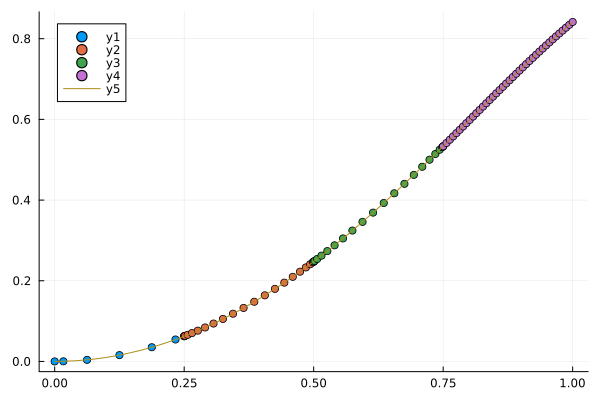

In [76]:
scatter(grids, funpts)
plot!(testfun)

In [78]:
derpts = ComputeSingleDerivative(funpts);

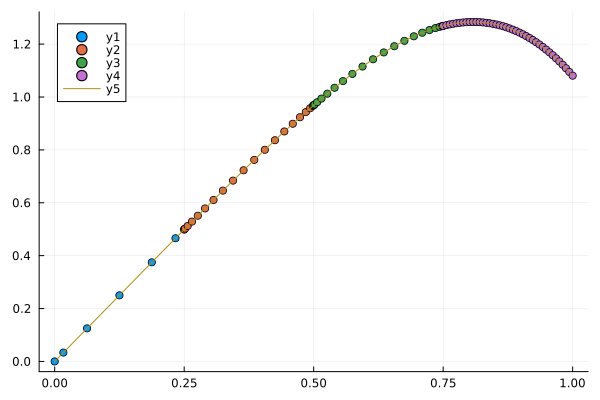

In [80]:
scatter(grids, derpts)
plot!(testder)